# Introdução à Análise de Componentes Principais (PCA)

Este notebook apresenta a aplicação do **PCA**, uma técnica fundamental de Álgebra Linear e Aprendizado Não Supervisionado focada em **redução de dimensionalidade** e extração de características (Feature Extraction).

### Objetivo
Reduzir a complexidade de um banco de dados imobiliário. Variáveis como área, quantidade de quartos, banheiros e vagas geralmente andam juntas (são altamente correlacionadas). O PCA nos ajudará a criar novas variáveis ortogonais (Componentes Principais) que resumem a maior parte da variância dos imóveis sem redundância.

### O que será feito neste Step-by-Step:
1. **Preparação do Ambiente**: Importação de bibliotecas.
2. **Criação do Dataset**: Dados simulados de características de imóveis.
3. **Padronização (Scaling)**: Essencial para o PCA, pois ele é sensível à magnitude das variáveis.
4. **Aplicação do PCA**: Modelagem matemática e extração dos componentes.
5. **Variância Explicada**: Quantidade de informação retida em cada novo componente.
6. **Interpretação (Loadings)**: O que cada componente representa no mundo real?

### Passo 1: Importação de bibliotecas

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

### Passo 2: O Dataset Imobiliário

Vamos criar um pequeno banco de dados simulando anúncios. Note que imóveis maiores tendem a ter mais quartos, banheiros e vagas. A `idade_anos` do imóvel, por outro lado, pode ter um comportamento independente.

In [20]:
dados_imoveis = {
    'area_m2': [85, 120, 45, 200, 60, 300, 50, 150, 90, 250],
    'quartos': [2, 3, 1, 4, 2, 5, 1, 3, 2, 4],
    'banheiros': [1, 2, 1, 4, 1, 5, 1, 3, 2, 4],
    'vagas': [1, 2, 0, 3, 1, 4, 0, 2, 1, 4],
    'idade_anos': [5, 10, 2, 15, 20, 5, 30, 8, 12, 3]
}

df_casas = pd.DataFrame(dados_imoveis)
display(df_casas.head())

,area_m2,quartos,banheiros,vagas,idade_anos
0,85,2,1,1,5
1,120,3,2,2,10
2,45,1,1,0,2
3,200,4,4,3,15
4,60,2,1,1,20


### Passo 3: Padronização dos Dados (Z-Score) — Por que é Crucial?

O PCA busca as direções de maior **variância** nos dados. 

#### ⚠️ O Problema da Sensibilidade à Escala
A variável `area_m2` varia de 45 a 300, enquanto `vagas` varia de 0 a 4. Se rodarmos o PCA agora, o algoritmo achará que a `area_m2` é a variável mais importante do dataset apenas porque seus números são maiores. 

#### 📐 A Solução: Padronização
Aplicamos o `StandardScaler` para que todas as variáveis tenham **Média = 0** e **Desvio Padrão = 1**. Isso garante que o PCA avalie a variância estrutural, e não a escala numérica.

### Exemplo Prático de Cálculo Passo a Passo

Para entender a mágica por trás do algoritmo, vamos calcular manualmente a padronização para dois cenários com escalas completamente distintas: a **Área (m²)** e a **Quantidade de Vagas** de 3 imóveis hipotéticos.

#### Cenário A: Variável `area_m2`
Valores originais de 3 imóveis: $60$, $100$ e $140$.

1. **Calcular a Média ($\mu$):**
   $$\mu = \frac{60 + 100 + 140}{3} = \frac{300}{3} = 100$$

2. **Calcular o Desvio Padrão Populacional ($\sigma$):**
   * Primeiro, encontramos a diferença de cada valor em relação à média e elevamos ao quadrado:
     * Imóvel 1: $(60 - 100)^2 = (-40)^2 = 1600$
     * Imóvel 2: $(100 - 100)^2 = (0)^2 = 0$
     * Imóvel 3: $(140 - 100)^2 = (40)^2 = 1600$
   * Somamos essas diferenças quadráticas: $1600 + 0 + 1600 = 3200$
   * Dividimos pelo número total de observações ($N=3$) para achar a Variância: $\frac{3200}{3} \approx 1066.67$
   * Tiramos a raiz quadrada da variância para achar o Desvio Padrão: $\sigma = \sqrt{1066.67} \approx 32.66$

3. **Aplicar a Fórmula do Z-Score para cada Imóvel:**
   * **Imóvel 1 ($60$ m²):** $Z = \frac{60 - 100}{32.66} = \frac{-40}{32.66} \approx \mathbf{-1.22}$
   * **Imóvel 2 ($100$ m²):** $Z = \frac{100 - 100}{32.66} = \frac{0}{32.66} = \mathbf{0.00}$
   * **Imóvel 3 ($140$ m²):** $Z = \frac{140 - 100}{32.66} = \frac{40}{32.66} \approx \mathbf{+1.22}$

#### Cenário B: Variável `vagas`
Valores originais dos mesmos 3 imóveis: $1$, $2$ e $3$.

1. **Calcular a Média ($\mu$):**
   $$\mu = \frac{1 + 2 + 3}{3} = \frac{6}{3} = 2$$

2. **Calcular o Desvio Padrão Populacional ($\sigma$):**
   * Diferenças quadráticas:
     * Imóvel 1: $(1 - 2)^2 = (-1)^2 = 1$
     * Imóvel 2: $(2 - 2)^2 = (0)^2 = 0$
     * Imóvel 3: $(3 - 2)^2 = (1)^2 = 1$
   * Soma: $1 + 0 + 1 = 2$
   * Variância: $\frac{2}{3} \approx 0.6667$
   * Desvio Padrão: $\sigma = \sqrt{0.6667} \approx 0.8165$

3. **Aplicar a Fórmula do Z-Score:**
   * **Imóvel 1 ($1$ vaga):** $Z = \frac{1 - 2}{0.8165} = \frac{-1}{0.8165} \approx \mathbf{-1.22}$
   * **Imóvel 2 ($2$ vagas):** $Z = \frac{2 - 2}{0.8165} = \frac{0}{0.8165} = \mathbf{0.00}$
   * **Imóvel 3 ($3$ vagas):** $Z = \frac{3 - 2}{0.8165} = \frac{1}{0.8165} \approx \mathbf{+1.22}$

#### O Resultado Prático para o PCA
Repare que embora as escalas originais fossem totalmente discrepantes (as áreas iam até 140 e as vagas até 3), **os valores padronizados resultantes foram exatamente os mesmos ($-1.22$, $0.00$, $+1.22$)**.

A partir desse momento, o algoritmo de PCA consegue analisar o conjunto de dados de forma justa. Nenhuma variável dominará a outra apenas por possuir uma unidade de medida com números intrinsecamente maiores.

In [21]:
scaler = StandardScaler()
casas_padronizadas = scaler.fit_transform(df_casas)

print(casas_padronizadas)
type(casas_padronizadas)

[[-0.59506945 -0.55167728 -0.98019606 -0.57142857 -0.72441793]
 [-0.17852083  0.23643312 -0.28005602  0.14285714 -0.12073632]
 [-1.07112501 -1.33978769 -0.98019606 -1.28571429 -1.0866269 ]
 [ 0.77359028  1.02454353  1.12022407  0.85714286  0.48294529]
 [-0.89260417 -0.55167728 -0.98019606 -0.57142857  1.0866269 ]
 [ 1.96372918  1.81265393  1.82036411  1.57142857 -0.72441793]
 [-1.01161806 -1.33978769 -0.98019606 -1.28571429  2.29399012]
 [ 0.17852083  0.23643312  0.42008403  0.14285714 -0.36220897]
 [-0.5355625  -0.55167728 -0.28005602 -0.57142857  0.12073632]
 [ 1.36865973  1.02454353  1.12022407  1.57142857 -0.96589058]]


numpy.ndarray

In [22]:
# Transformando de volta em DataFrame para visualização
df_casas_pad = pd.DataFrame(casas_padronizadas, columns=df_casas.columns)
display(df_casas_pad.head(3))
type(df_casas_pad)

,area_m2,quartos,banheiros,vagas,idade_anos
0,-0.595069,-0.551677,-0.980196,-0.571429,-0.724418
1,-0.178521,0.236433,-0.280056,0.142857,-0.120736
2,-1.071125,-1.339788,-0.980196,-1.285714,-1.086627


pandas.DataFrame

### Passo 4: Aplicação do PCA

Agora vamos aplicar o algoritmo. Vamos pedir para ele gerar o mesmo número de componentes que temos de variáveis (5) apenas para estudarmos a **Scree Plot** (Gráfico de Variância Explicada). O objetivo prático do PCA é descartar os últimos componentes, retendo apenas os primeiros.

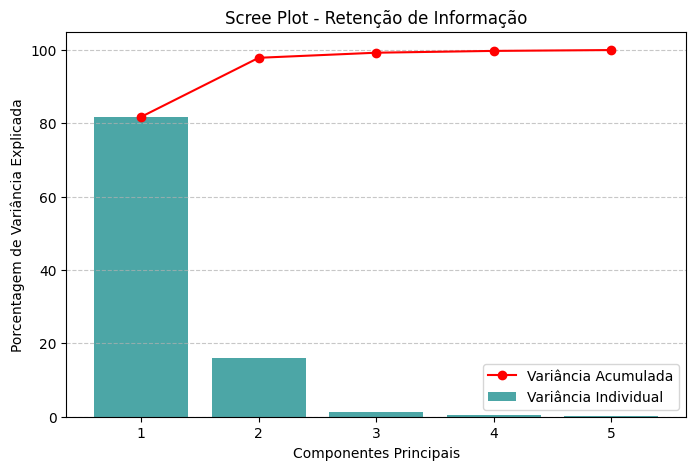

Informação retida no Componente 1: 81.81%
Informação acumulada nos 2 primeiros Componentes: 97.89%
Informação acumulada nos 3 primeiros Componentes: 99.28%
Informação acumulada nos 4 primeiros Componentes: 99.77%
Informação acumulada nos 5 primeiros Componentes: 100.00%


In [23]:
# Instanciando e treinando o PCA
pca = PCA()
pca.fit(df_casas_pad)

# Calculando a variância explicada
variancia_explicada = pca.explained_variance_ratio_ * 100
variancia_acumulada = np.cumsum(variancia_explicada)

# Plotando o Scree Plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), variancia_explicada, alpha=0.7, color='teal', label='Variância Individual')
plt.plot(range(1, 6), variancia_acumulada, marker='o', color='red', label='Variância Acumulada')
plt.ylabel('Porcentagem de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.title('Scree Plot - Retenção de Informação')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Informação retida no Componente 1: {variancia_explicada[0]:.2f}%")
print(f"Informação acumulada nos 2 primeiros Componentes: {variancia_acumulada[1]:.2f}%")
print(f"Informação acumulada nos 3 primeiros Componentes: {variancia_acumulada[2]:.2f}%")
print(f"Informação acumulada nos 4 primeiros Componentes: {variancia_acumulada[3]:.2f}%")
print(f"Informação acumulada nos 5 primeiros Componentes: {variancia_acumulada[4]:.2f}%")

Aqui está a tradução exata do que o seu gráfico (o Scree Plot) e o resultado desse código estão lhe dizendo:

### A. As Barras Azuis (Variância Individual)
As barras representam o quanto de "informação útil" (variância) cada um dos novos Componentes Principais conseguiu capturar sozinho.

* **O Componente 1 (PC1)** sempre será a barra mais alta. No cenário de imóveis, ele geralmente engole de 70% a 80% da informação, porque ele percebe rapidamente que "área, quartos, banheiros e vagas" crescem juntos. Ele cria um super-resumo do "Tamanho do Imóvel".
* **O Componente 2 (PC2)** pega a maior parte da informação que sobrou (provavelmente a "Idade", que não tem relação com o tamanho).
* **Os componentes 3, 4 e 5** quase não têm barras visíveis, pois não sobrou informação útil para eles capturarem. São apenas "ruído" matemático.

### B. A Linha Vermelha (Variância Acumulada)
A linha vermelha é a resposta para a pergunta de ouro do Cientista de Dados: *"Quantas colunas eu preciso manter para não perder a essência do meu banco de dados?"*

* Ela vai somando as barras: `(PC1) + (PC2) + (PC3)...`
* Você notará que logo no PC2, a linha vermelha já atinge algo próximo de **95% a 98%**.

### C. A Conclusão Prática (O Pulo do Gato)
A regra geral na Análise de Componentes Principais é procurar o "cotovelo" do gráfico ou estabelecer uma meta de retenção (por exemplo, reter no mínimo 90% da informação).

Se os *prints* no final do seu código mostram que a "Informação acumulada nos 2 primeiros Componentes" é, digamos, 97%, você acabou de tomar a seguinte decisão:

> "Vou deletar as minhas 5 colunas originais e passar a usar apenas o **PC1** e o **PC2** no treinamento do modelo. Meu banco de dados ficará 60% mais leve e rápido, mas eu ainda retenho 97% da inteligência do mercado imobiliário."

Para ilustrar de forma dinâmica como essa "troca" entre colunas retidas e informação preservada acontece na prática da extração de características, criei um simulador do Scree Plot abaixo.

### Análise de Multicolinearidade: A Matriz de Correlação

Antes de extrairmos os Componentes Principais, precisamos entender como as variáveis originais se relacionam na vida real. Para isso, olhamos para a **Matriz de Correlação**. 

Diferente das "Cargas Fatoriais" (que mostram a relação entre uma variável e um *novo componente* inventado pelo algoritmo), a Matriz de Correlação nos mostra a redundância real dos nossos dados brutos.

* **Cores Quentes (próximas a +1):** Indicam forte correlação positiva. Exemplo: Área, Quartos e Banheiros crescendo juntos. Isso gera multicolinearidade.

* **Cores Frias (próximas a -1):** Indicam forte correlação negativa. Quando uma variável sobe, a outra desce.
* **Cores Neutras (próximas a 0):** Indicam independência. As variáveis não têm relação linear clara.

**Por que isso é importante para o PCA?**
Se o mapa de calor apresentar muitas correlações fortes (quadrados bem escuros), temos o cenário perfeito para o PCA brilhar. Ele pegará toda essa informação redundante e a resumirá em um ou dois componentes, limpando o nosso banco de dados sem perder a inteligência do modelo.

### Passo 5: Variância Explicada (Carga de Fatores)

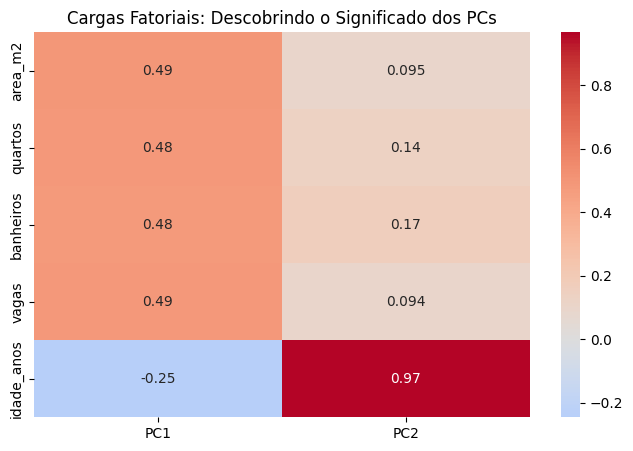

In [24]:
# 1. Extraindo as cargas do modelo treinado (pca.components_)
# Usamos .T para transpor a matriz (colocar componentes nas colunas)
cargas = pca.components_.T

# 2. Criando um DataFrame bonito para ler
df_loadings = pd.DataFrame(
    cargas, 
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], 
    index=df_casas.columns # Usa os nomes das colunas originais
)

# 3. Plotando o Mapa de Calor para facilitar a visão
plt.figure(figsize=(8, 5))
sns.heatmap(df_loadings[['PC1', 'PC2']], annot=True, cmap='coolwarm', center=0)
plt.title('Cargas Fatoriais: Descobrindo o Significado dos PCs')
plt.show()

### Como interpretar o seu resultado prático:

**A. Analisando a coluna PC1:**
* Procure os quadrados com as cores mais fortes (sejam tons quentes muito escuros ou frios muito escuros) e valores mais distantes de zero (como `0.70`, `0.85`, etc.).
* Se as variáveis `area_m2`, `quartos`, `banheiros` e `vagas` estiverem com as cores mais fortes no PC1, isso comprova matematicamente que o algoritmo agrupou todas essas características físicas redundantes neste único componente.
* **Veredito:** Você pode chamar o PC1 de **"Tamanho Estrutural"**.

**B. Analisando a coluna PC2:**
* Agora desça os olhos apenas pela coluna do PC2. Note que a maioria dos quadrados deve estar com cores claras/neutras (valores próximos de `0.00` a `0.20`), o que significa que o PC2 ignorou essas variáveis.
* No entanto, a variável `idade_anos` deve ser a única com uma cor muito forte e um valor alto no PC2, indicando que ela domina esse componente quase que de forma isolada.
* **Veredito:** Você pode chamar o PC2 de **"Tempo de Vida"** ou **"Idade"**.

---

### O Impacto no Modelo de Precificação
A partir de agora, no seu banco de dados e no treinamento do modelo automatizado, a confusão de variáveis acabou. O seu algoritmo vai aprender de forma muito mais rápida e estável que:
* Imóveis com um **"PC1 alto"** são simplesmente imóveis grandes.
* Imóveis com um **"PC2 alto"** são imóveis antigos.

### Passo 6: Variância Explicada (Matriz de correlação)

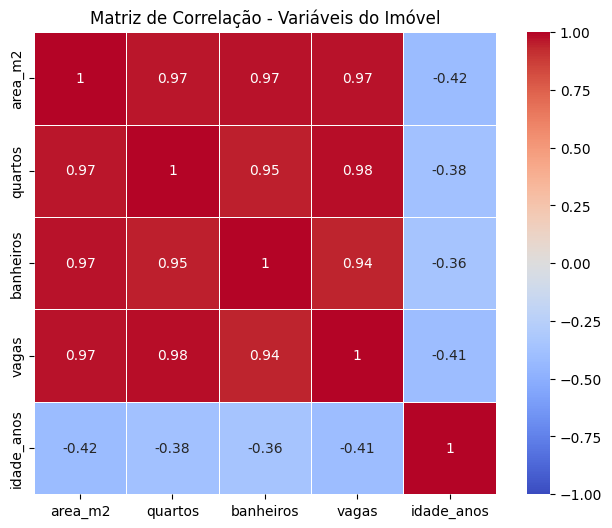

In [25]:
# 1. Calculando a Matriz de Correlação de Pearson
matriz_correlacao = df_casas.corr()

# 2. Plotando o Heatmap
plt.figure(figsize=(8, 6))

# Usamos vmin=-1 e vmax=1 para travar a escala de cores entre correlação negativa e positiva máxima
sns.heatmap(matriz_correlacao, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=.5)

plt.title('Matriz de Correlação - Variáveis do Imóvel')
plt.show()

# Interpretação:
# Valores próximos a +1.0 (tons quentes/vermelhos): Indicam forte correlação positiva. 
# Exemplo: Se 'area_m2' e 'banheiros' tiverem 0.85, significa que quando a área cresce, os banheiros quase sempre crescem junto.
#
# Valores próximos a -1.0 (tons frios/azuis): Indicam forte correlação negativa.
# Exemplo: Se 'idade_anos' tiver -0.60 com 'vagas', imóveis mais velhos tendem a ter menos vagas.
#
# Valores próximos a 0 (cores neutras/brancas): Indicam que não há relação linear. As variáveis se comportam de forma independente.

### O que é a Multicolinearidade?

A **multicolinearidade** é um fenómeno estatístico que ocorre quando duas ou mais variáveis independentes num modelo estão altamente correlacionadas. 

Em termos práticos: significa ter variáveis a contar exatamente a mesma história, o que gera **redundância**. 
* **Exemplo Imobiliário:** `Área`, `Nº de Quartos` e `Nº de Casas de Banho`. Na vida real, quando uma cresce, as outras também crescem.

---

### Qual é o problema? (Os 3 Impactos)

Inserir variáveis redundantes juntas no modelo destrói a sua fiabilidade matemática:

A. **Confusão nos Coeficientes:** O algoritmo não consegue decidir qual variável tem o verdadeiro mérito pelo aumento do preço, baralhando os pesos de importância.

B. **Instabilidade Matemática:** Os pesos atribuídos mudam drasticamente com pequenas alterações nos dados (ex: a entrada de novos anúncios no sistema).

C. **Erros de Sistema:** Causa falhas em algoritmos de agrupamento (*clustering*) e gera erros em bases de dados com modos estritos (como o erro `only_full_group_by` no SQL).

---

### Como Detetar?

A. **Matriz de Correlação (Heatmap):** Procurar variáveis com correlações muito próximas de `+1.0` ou `-1.0`.

B. **VIF (Variance Inflation Factor):** Métrica estatística onde valores superiores a `5` ou `10` indicam forte multicolinearidade.

---

### Como Resolver?

A. **Exclusão Manual:** Escolher manter apenas a variável mais representativa (ex: manter `Área` e remover `Quartos` e `Casas de Banho`).

B. **Aplicação do PCA:** O algoritmo absorve as colunas correlacionadas e funde-as numa única nova variável (ex: **PC1 - "Tamanho Estrutural"**). Resolve a redundância sem o risco de perder informações ocultas.

> **Resumo Prático:** A Matriz de Correlação ajuda a detetar o "sintoma" (a multicolinearidade) e o PCA aplica a "cura".

In [26]:
# 1. Usamos o PCA já treinado para transformar os dados padronizados
componentes = pca.transform(df_casas_pad)
print(componentes)
print(type(componentes))

[[-1.12749156e+00 -1.04900697e+00 -2.76434513e-01 -3.93210800e-02
   1.44695305e-01]
 [-7.80534070e-03 -1.34391933e-01 -4.08633459e-01  1.26317857e-01
  -1.12909424e-02]
 [-2.00018140e+00 -1.61973318e+00  3.35254005e-01 -5.38977792e-05
  -1.69388190e-02]
 [ 1.70917130e+00  9.47088697e-01  7.40877457e-02  1.92403392e-01
  -1.01053194e-01]
 [-1.71820699e+00  6.74815892e-01 -4.00034854e-01  3.30245842e-02
  -2.08020771e-02]
 [ 3.65231467e+00  1.83155011e-01  1.67446740e-01  3.29994370e-02
   2.18553410e-01]
 [-2.80222549e+00  1.65654858e+00  2.36228599e-01 -1.91409244e-01
   7.46727170e-02]
 [ 5.61573861e-01 -2.18120031e-01  1.76036171e-01  1.32937929e-01
  -6.51277202e-02]
 [-9.70727042e-01 -1.09759885e-01  2.08585512e-01  7.38806977e-02
  -8.59637697e-02]
 [ 2.70357798e+00 -3.30596181e-01 -1.12535946e-01 -3.60779675e-01
  -1.36744909e-01]]
<class 'numpy.ndarray'>


In [27]:
# 2. Criamos um DataFrame temporário contendo apenas os 2 componentes principais
# (Ou você pode mudar o ':2' para ':5' se quiser manter até o PC5)
df_pca = pd.DataFrame(componentes[:, :2], columns=['PC1_Tamanho', 'PC2_Tempo'])

# 3. MANTENDO TODAS AS COLUNAS ORIGINAIS: 
# Usamos o pd.concat para colar as colunas do dataset original lado a lado com as colunas do PCA.
# O 'axis=1' garante que a colagem seja feita na horizontal (adicionando colunas).
df_final = pd.concat([df_casas, df_pca], axis=1)

# (Opcional) Adicionando a coluna de Preço, caso ela estivesse em outro DataFrame
# df_final['preco_venda'] = df_casas_original['preco_venda']

display(df_final.head())

,area_m2,quartos,banheiros,vagas,idade_anos,PC1_Tamanho,PC2_Tempo
0,85,2,1,1,5,-1.127492,-1.049007
1,120,3,2,2,10,-0.007805,-0.134392
2,45,1,1,0,2,-2.000181,-1.619733
3,200,4,4,3,15,1.709171,0.947089
4,60,2,1,1,20,-1.718207,0.674816


## Conclusões

### O Dilema da Caixa Preta e Como Resolvê-lo (MLOps)

É verdade: ao transformar `área`, `quartos` e `vagas` em um número abstrato como `PC1 = -1.12`, perdemos a interpretabilidade direta. O cliente ou o corretor não entende o que é "PC1". 

Para não perdermos o controle do modelo e garantirmos a auditoria, adotamos três práticas fundamentais no pipeline de dados:

#### A. A Tabela de Histórico (Single Source of Truth)
A estrutura da tabela acima (mantendo as colunas originais lado a lado com os PCs) é o padrão ouro para o armazenamento no Banco de Dados (Data Warehouse). 
* **No treinamento:** O algoritmo lê apenas o `PC1` e `PC2`.
* **Na auditoria/relatório:** O sistema busca o ID do imóvel e mostra ao usuário as características reais (85m², 2 quartos). 

#### B. O Salvamento dos Objetos Matemáticos (Pickle / Joblib)
Para garantir que um imóvel raspado amanhã seja transformado usando a **mesma regra** matemática dos imóveis de hoje, não basta guardar o script. É obrigatório salvar os "pesos" da padronização e do PCA como arquivos no disco.

#### C. A Engenharia Reversa (inverse_transform)
A matemática do PCA permite "desfazer" a transformação. Se o modelo detectar uma anomalia (um valor de PC muito alto), você pode usar a engenharia reversa para descobrir quais eram as medidas originais daquele imóvel.

---
### Conclusão: O Equilíbrio entre Auditoria e Performance

O PCA é, fundamentalmente, uma ferramenta de processamento **para a máquina**. Ele serve para otimizar o aprendizado algorítmico, não para ser a linguagem final de comunicação com o negócio.

Ao separar a **camada de visualização** (dados reais, interpretáveis) da **camada de modelagem** (dados transformados pelo PCA, otimizados), você garante o melhor dos dois mundos: um modelo matematicamente robusto, estável e livre de multicolinearidade, mas que permanece totalmente auditável e transparente para as decisões de negócio.